# 02 — Preprocessing Tests (Face Detection, Cropping, Resize, Normalize, Augment)

This notebook validates preprocessing steps aligned with methodology and implementation checklist:
- Face detection and cropping (for datasets requiring uncropped faces)
- Image resizing to target resolution (224×224)
- Image normalization (ImageNet mean/std)
- Data augmentation tests:
  - Horizontal flip
  - Random brightness/contrast
  - Mild rotation (±10°)
  - Light random crop/zoom
- Visual validation on a small sample

In [15]:
# Bootstrap dependencies for this notebook kernel (safe to re-run)
%pip install -q numpy pandas pillow matplotlib opencv-python-headless albumentations mediapipe opencv-python

Note: you may need to restart the kernel to use updated packages.


In [16]:
from __future__ import annotations

import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_SIZE = (224, 224)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists() and (candidate / "docs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_ROOT = PROJECT_ROOT / "dataset" / "processed"
RAW_UTK_ROOT = PROJECT_ROOT / "dataset" / "raw" / "UTKFace"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed root: {PROCESSED_ROOT}")
print(f"Raw UTK root: {RAW_UTK_ROOT}")
print(f"Target size: {TARGET_SIZE}")

Project root: C:\Users\Mark\Projects\age-gender-cnn
Processed root: C:\Users\Mark\Projects\age-gender-cnn\dataset\processed
Raw UTK root: C:\Users\Mark\Projects\age-gender-cnn\dataset\raw\UTKFace
Target size: (224, 224)


In [17]:
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError("No metadata CSV found in dataset/processed. Run notebook 01 first.")

metadata_path = metadata_candidates[-1]
metadata_df = pd.read_csv(metadata_path)

required_cols = {"path", "age", "gender"}
missing = required_cols - set(metadata_df.columns)
if missing:
    raise ValueError(f"Metadata file is missing required columns: {missing}")

metadata_df = metadata_df.dropna(subset=["path", "age", "gender"]).reset_index(drop=True)
metadata_df["path"] = metadata_df["path"].astype(str)

print(f"Using metadata: {metadata_path.name}")
print(f"Rows available: {len(metadata_df):,}")
metadata_df[["path", "age", "gender"]].head()

Using metadata: utkface_metadata_20260222T084307Z.csv
Rows available: 23,708


,path,age,gender
0,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,100,0
1,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,100,0
2,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,100,1
3,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,100,1
4,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,100,1


In [18]:
@dataclass
class FaceDetectionResult:
    crop_rgb: Optional[np.ndarray]
    bbox_xyxy: Optional[Tuple[int, int, int, int]]
    method: str
    success: bool


class FaceCropper:
    def __init__(self, min_confidence: float = 0.5):
        self.min_confidence = min_confidence
        self.init_notes: List[str] = []
        self._mediapipe_fd = None

        self._cascades: Dict[str, cv2.CascadeClassifier] = {}
        cascade_specs = {
            "opencv_haar_default": "haarcascade_frontalface_default.xml",
            "opencv_haar_alt2": "haarcascade_frontalface_alt2.xml",
            "opencv_haar_profile": "haarcascade_profileface.xml",
        }

        for name, filename in cascade_specs.items():
            cascade_path = cv2.data.haarcascades + filename
            cascade = cv2.CascadeClassifier(cascade_path)
            if not cascade.empty():
                self._cascades[name] = cascade

        try:
            import mediapipe as mp

            self._mediapipe_fd = mp.solutions.face_detection.FaceDetection(
                model_selection=1,
                min_detection_confidence=min_confidence,
            )
            self.init_notes.append("MediaPipe legacy detector initialized.")
        except Exception as exc:
            self._mediapipe_fd = None
            self.init_notes.append(f"MediaPipe legacy detector unavailable ({exc}).")

        self.available_backends = []
        if self._mediapipe_fd is not None:
            self.available_backends.append("mediapipe_legacy")
        self.available_backends.extend(list(self._cascades.keys()))

        if not self.available_backends:
            raise RuntimeError("No face detector backend is available.")

        self.primary_backend = self.available_backends[0]
        self.init_notes.append(f"Available backends: {', '.join(self.available_backends)}")
        self.init_notes.append(f"Primary backend: {self.primary_backend}")

    @staticmethod
    def _expand_box(
        x1: int,
        y1: int,
        x2: int,
        y2: int,
        width: int,
        height: int,
        margin_x: float = 0.2,
        margin_top: float = 0.30,
        margin_bottom: float = 0.12,
    ) -> Tuple[int, int, int, int]:
        bw, bh = x2 - x1, y2 - y1
        mx = int(bw * margin_x)
        my_top = int(bh * margin_top)
        my_bottom = int(bh * margin_bottom)

        nx1 = max(0, x1 - mx)
        ny1 = max(0, y1 - my_top)
        nx2 = min(width, x2 + mx)
        ny2 = min(height, y2 + my_bottom)

        side = max(nx2 - nx1, ny2 - ny1)
        cx = (nx1 + nx2) // 2
        cy = (ny1 + ny2) // 2
        sx1 = max(0, cx - side // 2)
        sy1 = max(0, cy - side // 2)
        sx2 = min(width, sx1 + side)
        sy2 = min(height, sy1 + side)

        if sx2 - sx1 < side:
            sx1 = max(0, sx2 - side)
        if sy2 - sy1 < side:
            sy1 = max(0, sy2 - side)

        return int(sx1), int(sy1), int(sx2), int(sy2)

    @staticmethod
    def _largest_box(boxes: List[Tuple[int, int, int, int]]) -> Tuple[int, int, int, int]:
        return sorted(boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]), reverse=True)[0]

    def _detect_mediapipe_legacy(self, rgb_img: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
        if self._mediapipe_fd is None:
            return None

        h, w = rgb_img.shape[:2]
        results = self._mediapipe_fd.process(rgb_img)
        if not results or not results.detections:
            return None

        boxes = []
        for det in results.detections:
            box = det.location_data.relative_bounding_box
            x1 = int(max(0, box.xmin * w))
            y1 = int(max(0, box.ymin * h))
            x2 = int(min(w, (box.xmin + box.width) * w))
            y2 = int(min(h, (box.ymin + box.height) * h))
            if x2 > x1 and y2 > y1:
                boxes.append((x1, y1, x2, y2))

        return self._largest_box(boxes) if boxes else None

    def _detect_haar(self, rgb_img: np.ndarray, backend: str) -> Optional[Tuple[int, int, int, int]]:
        cascade = self._cascades.get(backend)
        if cascade is None:
            return None

        gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
        faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(36, 36))

        boxes = []
        for x, y, fw, fh in faces:
            boxes.append((x, y, x + fw, y + fh))

        if backend == "opencv_haar_profile":
            flipped = cv2.flip(gray, 1)
            faces_flip = cascade.detectMultiScale(flipped, scaleFactor=1.1, minNeighbors=5, minSize=(36, 36))
            width = gray.shape[1]
            for x, y, fw, fh in faces_flip:
                fx1 = width - (x + fw)
                fy1 = y
                fx2 = width - x
                fy2 = y + fh
                boxes.append((fx1, fy1, fx2, fy2))

        return self._largest_box(boxes) if boxes else None

    def set_primary_backend(self, backend: str) -> None:
        if backend not in self.available_backends:
            raise ValueError(f"Backend '{backend}' is not available. Available: {self.available_backends}")
        self.primary_backend = backend

    def detect_with_backend(self, rgb_img: np.ndarray, backend: str) -> FaceDetectionResult:
        h, w = rgb_img.shape[:2]

        if backend == "mediapipe_legacy":
            box = self._detect_mediapipe_legacy(rgb_img)
        else:
            box = self._detect_haar(rgb_img, backend)

        if box is None:
            return FaceDetectionResult(None, None, backend, False)

        x1, y1, x2, y2 = self._expand_box(*box, w, h)
        if x2 <= x1 or y2 <= y1:
            return FaceDetectionResult(None, None, backend, False)

        return FaceDetectionResult(rgb_img[y1:y2, x1:x2], (x1, y1, x2, y2), backend, True)

    def detect_and_crop(self, rgb_img: np.ndarray) -> FaceDetectionResult:
        ordered = [self.primary_backend] + [b for b in self.available_backends if b != self.primary_backend]
        for backend in ordered:
            result = self.detect_with_backend(rgb_img, backend)
            if result.success:
                return result
        return FaceDetectionResult(None, None, ordered[-1], False)


def read_rgb(path: str) -> np.ndarray:
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB"), dtype=np.uint8)


sample_n = 24
sample_df = metadata_df.sample(n=min(sample_n, len(metadata_df)), random_state=SEED).reset_index(drop=True)
cropper = FaceCropper(min_confidence=0.5)

for note in cropper.init_notes:
    print(note)
print(f"Testing on sample size: {len(sample_df)}")

MediaPipe legacy detector unavailable (module 'mediapipe' has no attribute 'solutions').
Available backends: opencv_haar_default, opencv_haar_alt2, opencv_haar_profile
Primary backend: opencv_haar_default
Testing on sample size: 24


In [19]:
import time

benchmark_rows = []
for _, row in sample_df.iterrows():
    rgb = read_rgb(row["path"])
    h, w = rgb.shape[:2]

    for backend in cropper.available_backends:
        t0 = time.perf_counter()
        det = cropper.detect_with_backend(rgb, backend)
        elapsed_ms = (time.perf_counter() - t0) * 1000.0

        area_ratio = 0.0
        if det.success and det.bbox_xyxy is not None:
            x1, y1, x2, y2 = det.bbox_xyxy
            area_ratio = ((x2 - x1) * (y2 - y1)) / float(h * w)

        benchmark_rows.append(
            {
                "backend": backend,
                "success": bool(det.success),
                "elapsed_ms": elapsed_ms,
                "area_ratio": area_ratio,
            }
        )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_summary = (
    benchmark_df.groupby("backend")
    .agg(
        success_rate=("success", "mean"),
        detections=("success", "sum"),
        total=("success", "count"),
        avg_latency_ms=("elapsed_ms", "mean"),
        median_latency_ms=("elapsed_ms", "median"),
        mean_area_ratio=("area_ratio", "mean"),
    )
    .sort_values(["success_rate", "avg_latency_ms"], ascending=[False, True])
    .reset_index()
)

best_backend = benchmark_summary.iloc[0]["backend"]
cropper.set_primary_backend(best_backend)

print("Benchmark summary (higher success_rate, lower latency is better):")
display(benchmark_summary)
print(f"Selected primary backend: {best_backend}")

Benchmark summary (higher success_rate, lower latency is better):


,backend,success_rate,detections,total,avg_latency_ms,median_latency_ms,mean_area_ratio
0,opencv_haar_alt2,0.583333,14,24,4.836667,4.6317,0.582093
1,opencv_haar_default,0.541667,13,24,2.729746,2.4994,0.505551
2,opencv_haar_profile,0.000000,0,24,8.099925,7.5908,0.000000


Selected primary backend: opencv_haar_alt2


In [20]:
test_records = []
for _, row in sample_df.iterrows():
    path = row["path"]
    try:
        rgb = read_rgb(path)
        det = cropper.detect_and_crop(rgb)
        crop = det.crop_rgb if det.success else rgb
        test_records.append(
            {
                "path": path,
                "age": float(row["age"]),
                "gender": int(row["gender"]),
                "detected": bool(det.success),
                "method": det.method,
                "bbox": det.bbox_xyxy,
                "original_rgb": rgb,
                "crop_rgb": crop,
            }
        )
    except Exception as exc:
        test_records.append(
            {
                "path": path,
                "age": float(row["age"]),
                "gender": int(row["gender"]),
                "detected": False,
                "method": "error",
                "bbox": None,
                "error": str(exc),
            }
        )

results_df = pd.DataFrame(
    [
        {
            "path": item["path"],
            "age": item["age"],
            "gender": item["gender"],
            "detected": item["detected"],
            "method": item["method"],
            "error": item.get("error", ""),
        }
        for item in test_records
    ]
)

detection_rate = float(results_df["detected"].mean()) if len(results_df) else 0.0
print(f"Face detection success rate: {detection_rate:.1%} ({results_df['detected'].sum()}/{len(results_df)})")
display(results_df[["detected", "method"]].value_counts().to_frame("count"))

error_rows = results_df[results_df["error"] != ""]
if not error_rows.empty:
    display(error_rows[["path", "error"]].head())

Face detection success rate: 62.5% (15/24)


,,count
detected,method,
True,opencv_haar_alt2,14
False,opencv_haar_profile,9
True,opencv_haar_default,1


In [21]:
def resize_image(rgb_img: np.ndarray, target_size: Tuple[int, int] = TARGET_SIZE) -> np.ndarray:
    return cv2.resize(rgb_img, target_size, interpolation=cv2.INTER_AREA)


def normalize_imagenet(rgb_img: np.ndarray) -> np.ndarray:
    arr = rgb_img.astype(np.float32) / 255.0
    return (arr - IMAGENET_MEAN) / IMAGENET_STD


def denormalize_imagenet(norm_img: np.ndarray) -> np.ndarray:
    arr = (norm_img * IMAGENET_STD + IMAGENET_MEAN).clip(0.0, 1.0)
    return (arr * 255.0).astype(np.uint8)


augmenter = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.RandomResizedCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], scale=(0.9, 1.0), ratio=(0.95, 1.05), p=0.6),
    ]
)

preprocessed_samples = []
for item in test_records:
    if "crop_rgb" not in item:
        continue

    crop_rgb = item["crop_rgb"]
    resized_rgb = resize_image(crop_rgb, TARGET_SIZE)
    normalized = normalize_imagenet(resized_rgb)
    augmented = augmenter(image=resized_rgb)["image"]

    preprocessed_samples.append(
        {
            "path": item["path"],
            "age": item["age"],
            "gender": item["gender"],
            "detected": item["detected"],
            "method": item["method"],
            "original_rgb": item["original_rgb"],
            "crop_rgb": crop_rgb,
            "resized_rgb": resized_rgb,
            "normalized": normalized,
            "augmented_rgb": augmented,
        }
    )

print(f"Preprocessed samples: {len(preprocessed_samples)}")

Preprocessed samples: 24


Normalized tensor stats:
  shape: (24, 224, 224, 3)
  min: -2.1179, max: 2.6400
  mean (global): 0.0991, std (global): 1.1366


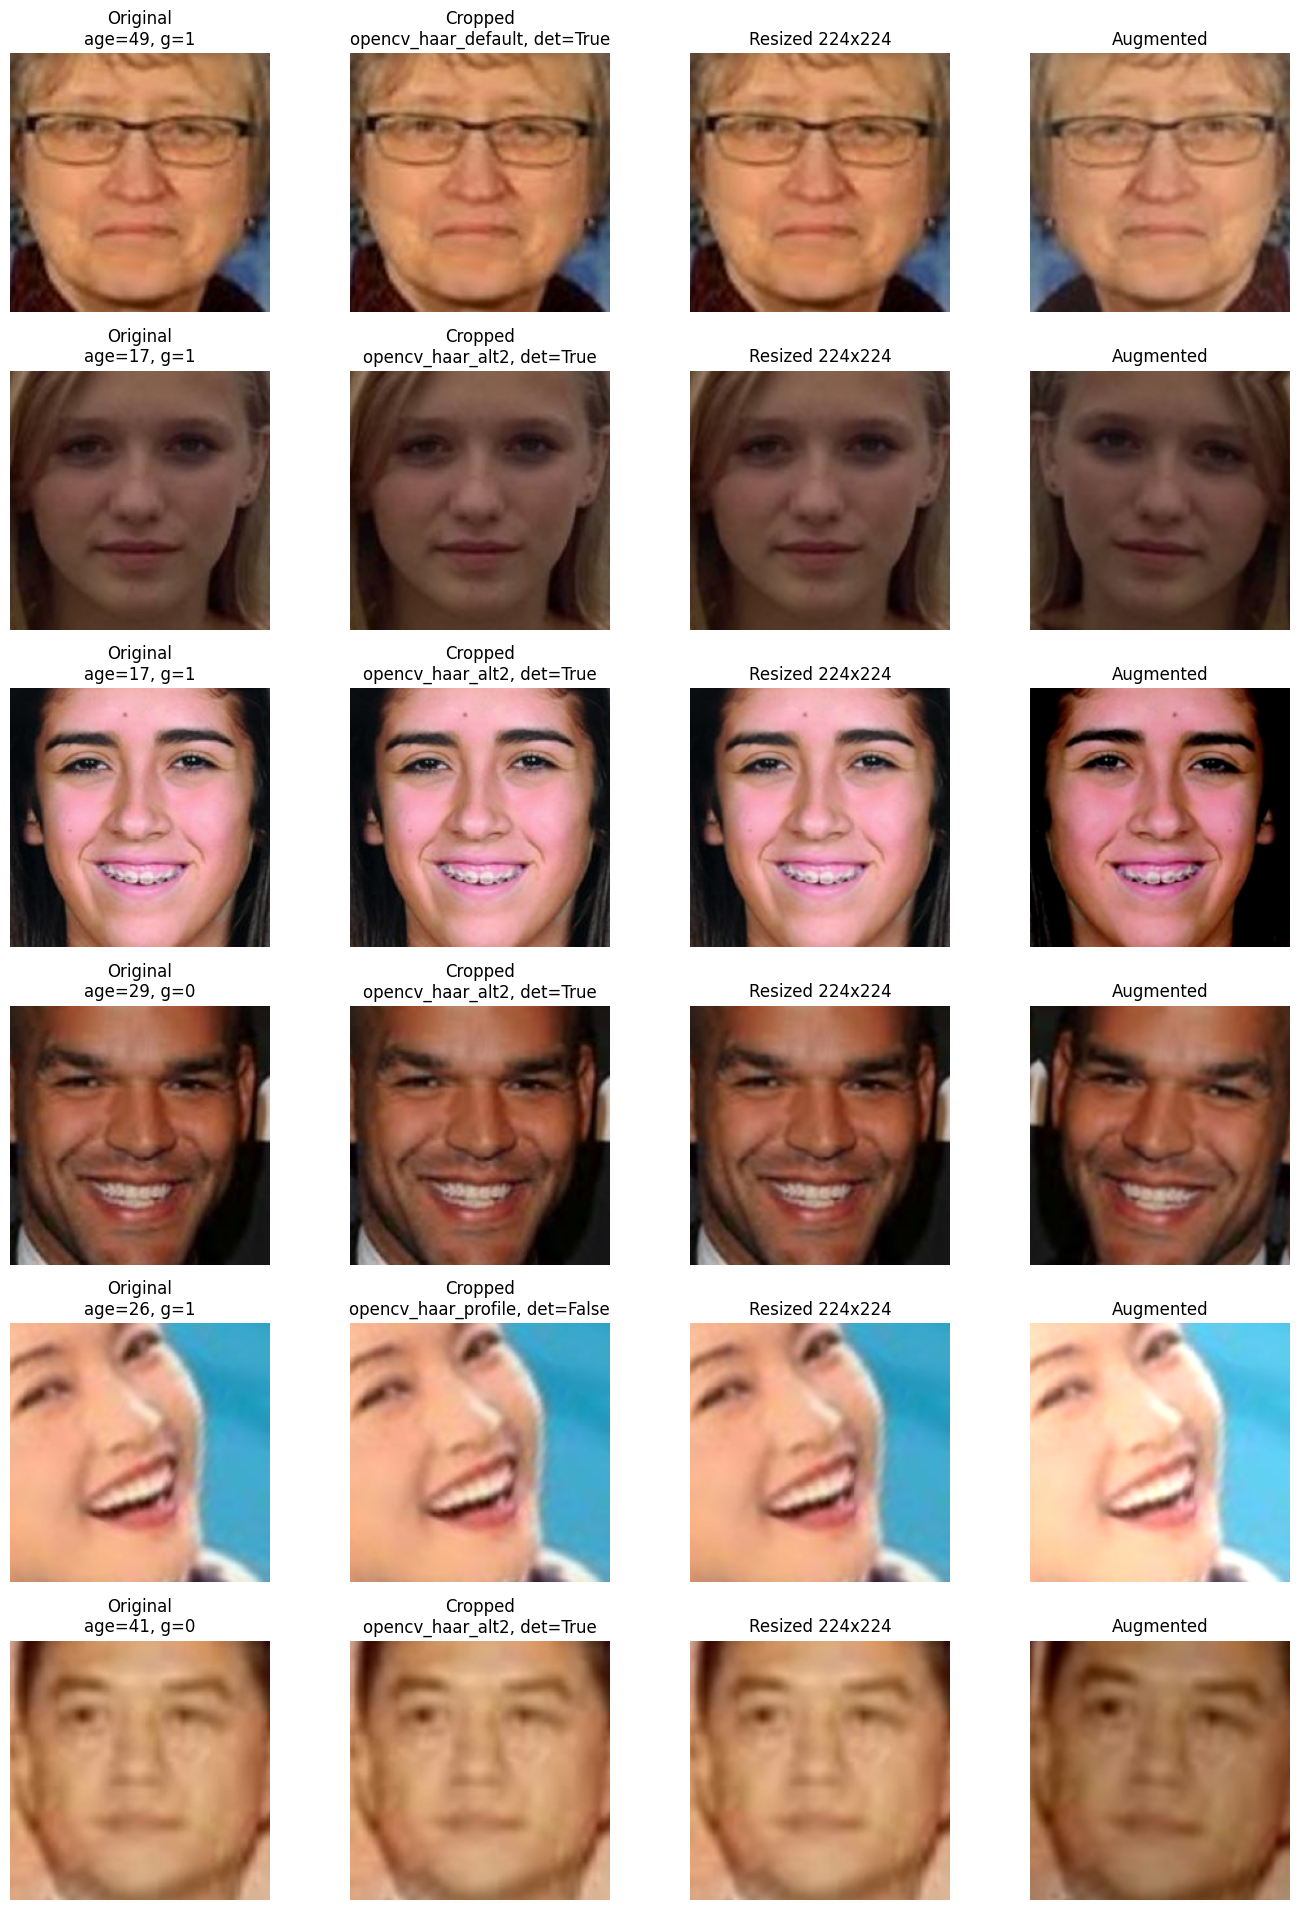

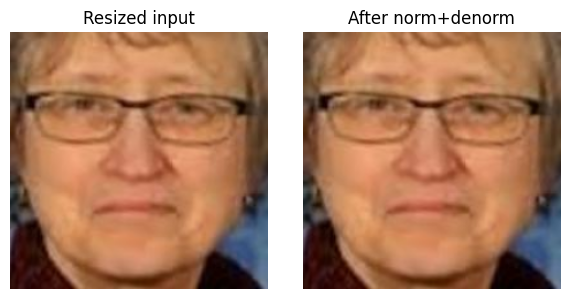

In [22]:
if not preprocessed_samples:
    raise RuntimeError("No preprocessed samples available for visualization.")

norm_stack = np.stack([s["normalized"] for s in preprocessed_samples], axis=0)
print("Normalized tensor stats:")
print(f"  shape: {norm_stack.shape}")
print(f"  min: {norm_stack.min():.4f}, max: {norm_stack.max():.4f}")
print(f"  mean (global): {norm_stack.mean():.4f}, std (global): {norm_stack.std():.4f}")

rows = min(6, len(preprocessed_samples))
fig, axes = plt.subplots(rows, 4, figsize=(14, rows * 3.2))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(rows):
    item = preprocessed_samples[i]
    axes[i, 0].imshow(item["original_rgb"])
    axes[i, 0].set_title(f"Original\nage={item['age']:.0f}, g={item['gender']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(item["crop_rgb"])
    axes[i, 1].set_title(f"Cropped\n{item['method']}, det={item['detected']}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(item["resized_rgb"])
    axes[i, 2].set_title(f"Resized {TARGET_SIZE[0]}x{TARGET_SIZE[1]}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(item["augmented_rgb"])
    axes[i, 3].set_title("Augmented")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

# Quick normalization visualization (de-normalized preview of first sample)
first = preprocessed_samples[0]
denorm_preview = denormalize_imagenet(first["normalized"])

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(first["resized_rgb"])
ax[0].set_title("Resized input")
ax[0].axis("off")
ax[1].imshow(denorm_preview)
ax[1].set_title("After norm+denorm")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Checklist Mapping

Completed in this notebook:
- Face detection/cropping test pipeline (with fallback detector)
- Resize to target resolution (224×224)
- ImageNet normalization check
- Data augmentation checks:
  - Horizontal flip
  - Random brightness/contrast
  - Mild rotation (±10°)
  - Light random crop/zoom
- Small sample visualization for preprocessing validation

Recommended next step:
- Move stable preprocessing utilities into `src/data/preprocessing.py` and keep this notebook as validation/QA.